In [ ]:
# !pip install PyCaret

# Start

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
df = pd.read_csv('/content/Dataset - Long beans.csv')

In [ ]:
df.head()

,Date,Retail Price,Inflation NCIP Food,Inflation NCIP Non Food,Inflation NCIP All Items,National Production
0,2014-01-01,93.59,14198.75000,18921.70000,33139.11000,4345.7
1,2014-02-01,91.75,14127.75625,18978.46510,33105.97089,4345.7
2,2014-03-01,88.47,14170.13952,18997.44357,33172.18283,4345.7
3,2014-04-01,85.06,14411.03189,19054.43590,33470.73248,3025.8
4,2014-05-01,119.51,14684.84150,19054.43590,33738.49834,3025.8


In [ ]:
df.rename(columns={
    'Retail Price': 'retail_price',
    'Inflation NCIP Food': 'ncpi_food',
    'Inflation NCIP Non Food': 'ncpi_non_food',
    'Inflation NCIP All Items': 'ncpi_all_items',
    'National Production': 'national_production',
}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 132 non-null    object 
 1   retail_price         129 non-null    float64
 2   ncpi_food            132 non-null    float64
 3   ncpi_non_food        132 non-null    float64
 4   ncpi_all_items       132 non-null    float64
 5   national_production  123 non-null    float64
dtypes: float64(5), object(1)
memory usage: 6.3+ KB


In [ ]:
df.describe()

,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,national_production
count,129.000000,132.000000,132.000000,132.000000,123.000000
mean,199.626667,25138.207213,30908.198703,55963.146748,5095.768293
std,96.314467,12167.347008,15218.021473,27317.687025,895.009468
min,85.060000,14127.756250,18844.597440,33105.970890,3025.800000
25%,132.870000,16772.795965,20683.920375,37177.949780,4345.700000
50%,161.360000,18684.351785,23739.449425,41634.862270,5243.300000
75%,250.810000,32173.716705,39309.011675,71463.339945,5865.300000
max,521.460000,48340.283560,61048.737030,108982.262800,6514.000000


In [ ]:
df.isnull().sum()

,0
Date,0
retail_price,3
ncpi_food,0
ncpi_non_food,0
ncpi_all_items,0
national_production,9


In [ ]:
df.drop(columns=["national_production"], inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Date,0
retail_price,0
ncpi_food,0
ncpi_non_food,0
ncpi_all_items,0


In [ ]:
df.reset_index(inplace=True)

In [ ]:
df["Date"] = df["Date"].astype("datetime64[ns]")
df["date"] = df["Date"].map(lambda x: (x).toordinal())
print(df[["Date", "date"]].head())
df.head()

        Date    date
0 2014-01-01  735234
1 2014-02-01  735265
2 2014-03-01  735293
3 2014-04-01  735324
4 2014-05-01  735354


,index,Date,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,2014-01-01,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,2014-02-01,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,2014-03-01,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,2014-04-01,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,2014-05-01,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           129 non-null    int64         
 1   Date            129 non-null    datetime64[ns]
 2   retail_price    129 non-null    float64       
 3   ncpi_food       129 non-null    float64       
 4   ncpi_non_food   129 non-null    float64       
 5   ncpi_all_items  129 non-null    float64       
 6   date            129 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 7.2 KB


In [ ]:
df.drop(columns=["Date"], inplace=True)

# Visualization

The trends of the price over time using a simple line plot

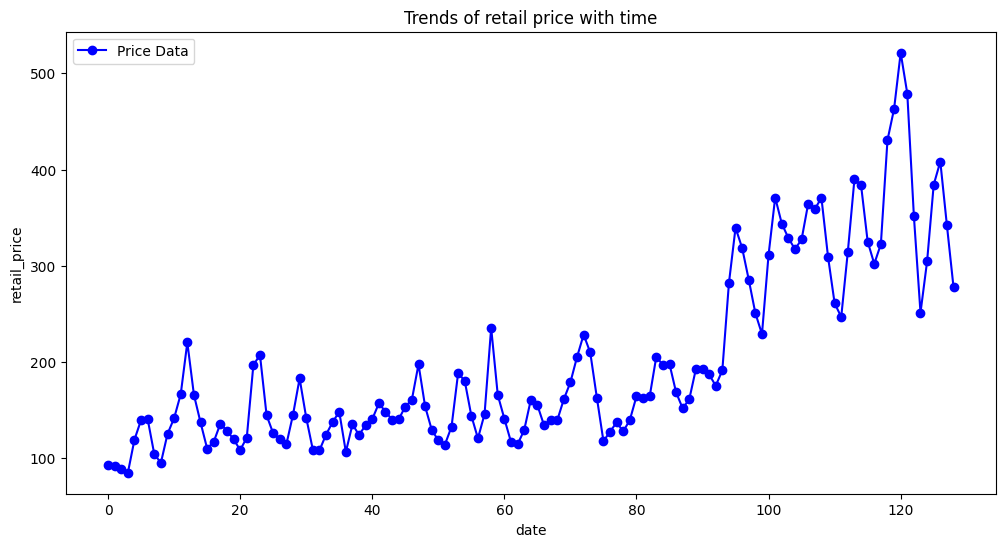

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['index'], df['retail_price'], marker='o', linestyle='-', color='b', label='Price Data')

# Labels and title
plt.xlabel('date')
plt.ylabel('retail_price')
plt.title('Trends of retail price with time')
plt.legend()

# Show grid and plot
plt.show()

The Seasonal decompose returns 4 plots.
1. General view of the data in thoughout time
2. Trends of the overall growth or loss of the values
3. Seasonality the common instances or actions in a given time period
4. Residual the values that do not fit the above 2 situations and are either random unexplained variations or just random noise

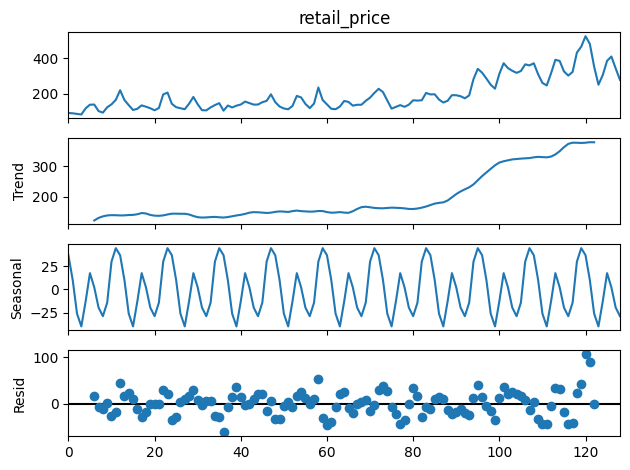

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df["retail_price"], model="additive", period=12)
decomposition.plot()
plt.show()

Trend --> The trend shows a small average growth until about 60% of the timeline, but afterwards a larger variance is visible.
Seasonal --> The series shows a strong seasonal behaviour
Residual --> There is a uniform residual spread throughout the time frame

The rolling mean/moving average will be used to smoothen values and identify the influence on the traget value due to external/other factors

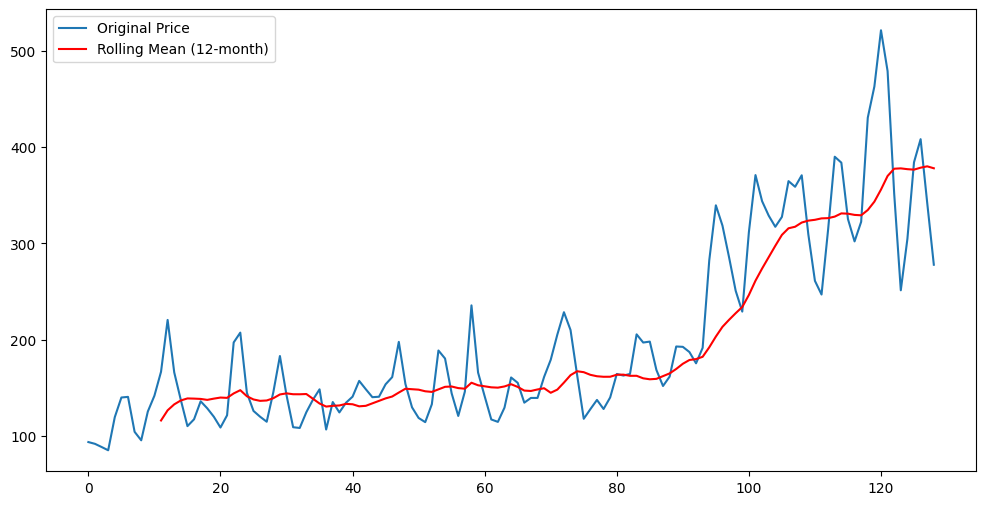

In [ ]:
df["rolling_mean"] = df["retail_price"].rolling(window=12).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['retail_price'], label="Original Price")
plt.plot(df["rolling_mean"], color="red", label="Rolling Mean (12-month)")
plt.legend()
plt.show()

The moving average shows a uniform and steady progression until about the x-axis 90 value, but there after the is a an extreme external factor that pushes the mean to a larger value, this is assumed to be the financial crisis of Sri Lanka and the high demand of produces during that time period. Additionally although the mean average shows a uniform straight line for most of the time there are distinguishable spikes and drops of values relative to the average, which can be due the a vital external factor which I assume to be the inflation.

Inflation NCIP Food

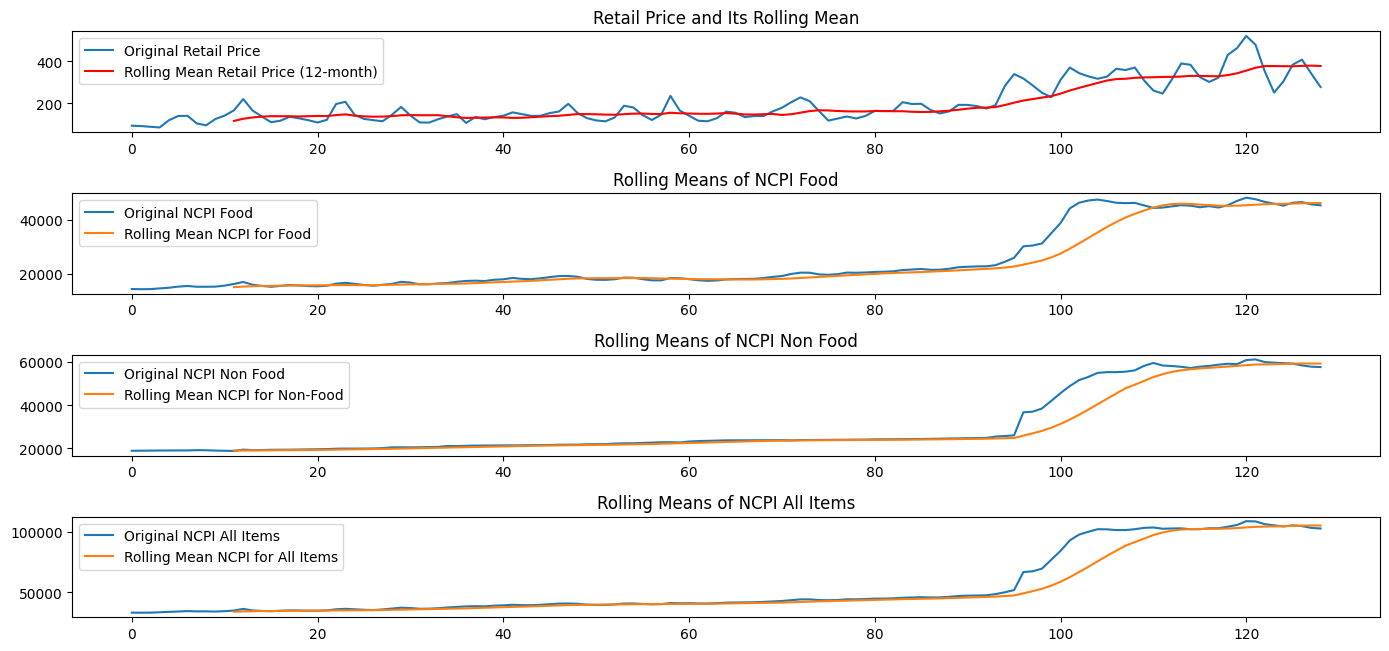

In [ ]:
df["rolling_mean_retail_price"] = df["retail_price"].rolling(window=12).mean()
df["rolling_mean_ncpi_food"] = df["ncpi_food"].rolling(window=12).mean()
df["rolling_mean_ncpi_non_food"] = df["ncpi_non_food"].rolling(window=12).mean()
df["rolling_mean_ncpi_all_items"] = df["ncpi_all_items"].rolling(window=12).mean()

plt.figure(figsize=(14, 8))

plt.subplot(5, 1, 1)
plt.plot(df['retail_price'], label="Original Retail Price")
plt.plot(df["rolling_mean_retail_price"], color="red", label="Rolling Mean Retail Price (12-month)")
plt.legend()
plt.title("Retail Price and Its Rolling Mean")

plt.subplot(5, 1, 2)
plt.plot(df['ncpi_food'], label="Original NCPI Food")
plt.plot(df["rolling_mean_ncpi_food"], label="Rolling Mean NCPI for Food")
plt.legend()
plt.title("Rolling Means of NCPI Food")

plt.subplot(5, 1, 3)
plt.plot(df['ncpi_non_food'], label="Original NCPI Non Food")
plt.plot(df["rolling_mean_ncpi_non_food"], label="Rolling Mean NCPI for Non-Food")
plt.legend()
plt.title("Rolling Means of NCPI Non Food")

plt.subplot(5, 1, 4)
plt.plot(df['ncpi_all_items'], label="Original NCPI All Items")
plt.plot(df["rolling_mean_ncpi_all_items"], label="Rolling Mean NCPI for All Items")
plt.legend()
plt.title("Rolling Means of NCPI All Items")


plt.tight_layout()
plt.show()

The mean for the NCIP seems to be very similar to the original value throughtout the plot, and the sudden change in the 90s range can be attributed to the financial crisis of Sri Lanka where the value of the Sri Lankan Ruppee greately deprciated. The NCPI means seems to have a highly similar mean trend to the retail price. The correlation of these 4 columns is expected to be over 0.7, which needs to be verified. The national production seems to have a several growth slopes especiall from aout 78 to 85 and a large drop from 85 to 98. This can be attributed to the poor quality of data taken for the national production.

Calculating the mean absolute error for the retail price and the NCPI

In [ ]:
from sklearn.metrics import r2_score
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Compute MAPE and R² for each rolling mean series
columns = ['ncpi_food', 'ncpi_non_food', 'ncpi_all_items', 'retail_price']
metrics = {}

for col in columns:
    y_true = df[col].dropna()
    y_pred = df[f'rolling_mean_{col}'].dropna()

    # Ensure both series have the same index after dropping NaNs
    y_true, y_pred = y_true.align(y_pred, join='inner')

    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    metrics[col] = {'MAPE': mape, 'R²': r2}

# Print results
for col, values in metrics.items():
    print(f"{col} -> MAPE: {values['MAPE']:.2f}%, R²: {values['R²']:.4f}")


ncpi_food -> MAPE: 5.46%, R²: 0.9158
ncpi_non_food -> MAPE: 4.61%, R²: 0.9208
ncpi_all_items -> MAPE: 4.66%, R²: 0.9207
retail_price -> MAPE: 15.41%, R²: 0.7607


As calculated above the NCPI mean absolute percentage error is less than 6% and the R² is over 0.9 shows a very accurate smoothing of the NCPI. The retail price has a moderate smoothening, this could be due to the seasonality and the high density of residuals which impact the calculations in the retail price. More verification through other smoothening evaluations are required for the confrimation of this. The national production has a highly inaccurate plot eventhough the MAPE is low which can be attributed to the low quality of data points. Hence it is reccomended to remove this column as it may affect the predictions that are to be made.

Verifing the correlation of the NCPI values with the retail price.

In [ ]:
df[['retail_price', 'ncpi_food', 'ncpi_non_food', 'ncpi_all_items']].corr()

,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items
retail_price,1.000000,0.910330,0.889157,0.900480
ncpi_food,0.910330,1.000000,0.991904,0.997537
ncpi_non_food,0.889157,0.991904,1.000000,0.998366
ncpi_all_items,0.900480,0.997537,0.998366,1.000000


As shown above is is evident that the ncip inflation has a significant impact on the retail price as all NCPI indexes exceed reached roughly 0.9. The national production shows a low correlation with retail price.

In [ ]:
df.tail()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date,rolling_mean,rolling_mean_retail_price,rolling_mean_ncpi_food,rolling_mean_ncpi_non_food,rolling_mean_ncpi_all_items
124,124,304.74,45364.99249,59350.03761,104572.2285,739007,377.140833,377.140833,46035.722366,58958.445632,104857.621525
125,125,384.32,46453.75231,59112.63746,105513.3785,739038,376.661667,376.661667,46111.891773,59080.317933,105066.019742
126,126,408.33,46686.02107,58285.06053,104880.2982,739068,378.697500,378.697500,46222.596817,59181.267298,105281.751950
127,127,342.04,45845.67269,57702.20993,103411.9741,739099,380.091667,380.091667,46312.410188,59181.328251,105375.123817
128,128,277.84,45478.90731,57529.10330,102894.9142,739130,378.069167,378.069167,46338.083842,59138.112912,105357.213017


<Figure size 1000x600 with 0 Axes>

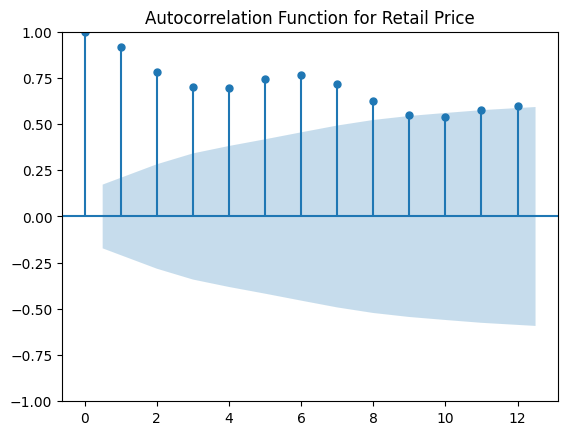

In [ ]:
plt.figure(figsize=(10, 6))
plot_acf(df['retail_price'], lags=12)
plt.title('Autocorrelation Function for Retail Price')
plt.show()

# Plot ACF for National Production
# plt.figure(figsize=(10, 6))
# plot_acf(df['National Production'], lags=40)  # Adjust lags as needed
# plt.title('Autocorrelation Function for National Production')
# plt.show()

<Figure size 1000x600 with 0 Axes>

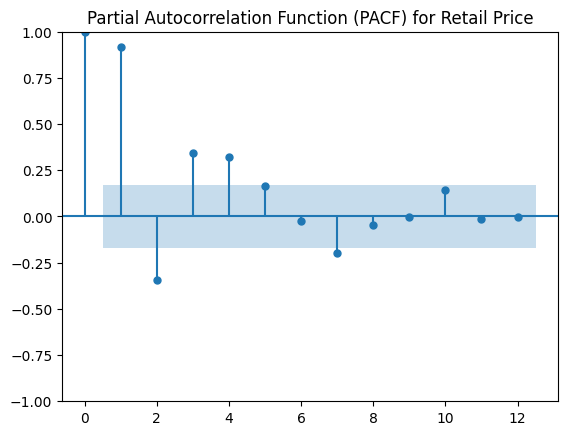

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_pacf(df['retail_price'], lags=12, method='ywm')  # 'ywm' is a stable method for PACF
plt.title('Partial Autocorrelation Function (PACF) for Retail Price')
plt.show()


Checking for outliers using IQR method

In [ ]:
import plotly.express as px

plt = px.box(df['retail_price'])
plt.show()

Although there are outliers present it cannot be reomved as all the values are extremely important. Hence the Z-score will be used to identify if the outliers instead of the IQR

Checking outliers using the Z-score

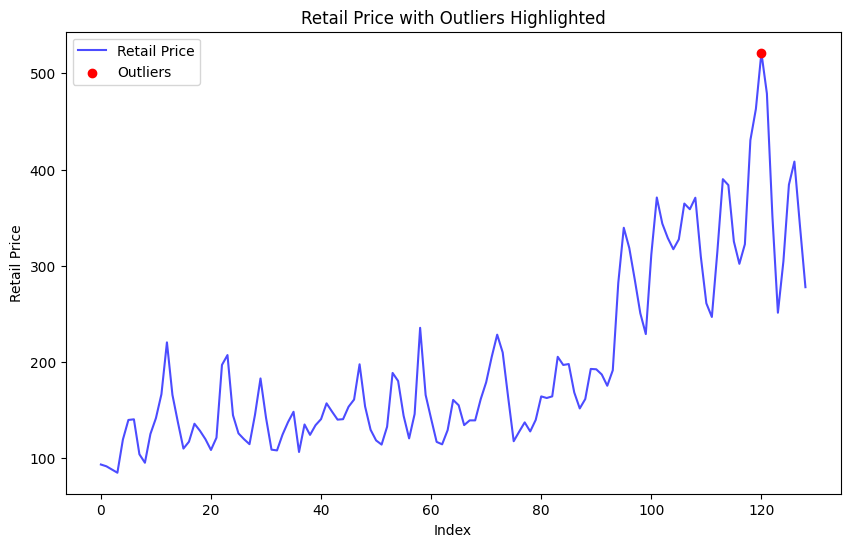

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import zscore

# Assuming df has a column 'retail_price'
df["z_score"] = zscore(df['retail_price'])

# Detect outliers (Z-score > 3 or < -3)
outliers = df[df["z_score"].abs() > 3]

# Plotting the retail_price and highlighting the outliers
plt.figure(figsize=(10, 6))
plt.plot(df['retail_price'], label='Retail Price', color='blue', alpha=0.7)
plt.scatter(outliers.index, outliers['retail_price'], color='red', label='Outliers', zorder=5)
plt.title('Retail Price with Outliers Highlighted')
plt.xlabel('Index')
plt.ylabel('Retail Price')
plt.legend()
plt.show()

As observed above there are only 2 outliers, hence I have decided to keep the outliers and progress.

In [ ]:
df.head()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date,rolling_mean,rolling_mean_retail_price,rolling_mean_ncpi_food,rolling_mean_ncpi_non_food,rolling_mean_ncpi_all_items,z_score
0,0,93.59,14198.75000,18921.70000,33139.11000,735234,NaN,NaN,NaN,NaN,NaN,-1.105234
1,1,91.75,14127.75625,18978.46510,33105.97089,735265,NaN,NaN,NaN,NaN,NaN,-1.124413
2,2,88.47,14170.13952,18997.44357,33172.18283,735293,NaN,NaN,NaN,NaN,NaN,-1.158601
3,3,85.06,14411.03189,19054.43590,33470.73248,735324,NaN,NaN,NaN,NaN,NaN,-1.194144
4,4,119.51,14684.84150,19054.43590,33738.49834,735354,NaN,NaN,NaN,NaN,NaN,-0.835067


In [ ]:
df.drop(columns=["rolling_mean", "rolling_mean_retail_price", "rolling_mean_ncpi_food", "rolling_mean_ncpi_non_food", "rolling_mean_ncpi_all_items", "z_score"], axis=1, inplace=True)

In [ ]:
df.columns

Index(['index', 'retail_price', 'ncpi_food', 'ncpi_non_food', 'ncpi_all_items',
       'date'],
      dtype='object')

In [ ]:
df.to_csv("prepared_long_beans.csv")

In [ ]:
df.head()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
df.head()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
# df.to_csv("prepared2_long_beans.csv")

# Pipeline

In [ ]:
prep_df = pd.read_csv("/content/prepared_long_beans.csv")

In [ ]:
df.head()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
from pycaret.regression import *

In [ ]:
clf = setup(data=prep_df, target='retail_price', session_id=777)

,Description,Value
0,Session id,777
1,Target,retail_price
2,Target type,Regression
3,Original data shape,"(129, 7)"
4,Transformed data shape,"(129, 7)"
5,Transformed train set shape,"(90, 7)"
6,Transformed test set shape,"(39, 7)"
7,Numeric features,6
8,Preprocess,True
9,Imputation type,simple


In [ ]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,21.0916,999.2178,30.3680,0.8869,0.1290,0.1027,0.1610
knn,K Neighbors Regressor,24.6410,1102.6859,32.2802,0.8769,0.1659,0.1353,0.0280
rf,Random Forest Regressor,23.5154,1185.8193,33.4822,0.8632,0.1473,0.1182,0.2380
huber,Huber Regressor,22.9888,1200.4320,32.9832,0.8592,0.1529,0.1172,0.0370
br,Bayesian Ridge,24.6300,1220.4621,33.7253,0.8508,0.1608,0.1309,0.0220
ada,AdaBoost Regressor,26.3833,1273.8497,34.9757,0.8508,0.1660,0.1421,0.0770
lasso,Lasso Regression,24.4757,1222.1877,33.5769,0.8503,0.1581,0.1289,0.0220
en,Elastic Net,24.4768,1222.2129,33.5773,0.8503,0.1581,0.1289,0.0260
llar,Lasso Least Angle Regression,24.6440,1224.6122,33.5732,0.8501,0.1570,0.1288,0.0230
ridge,Ridge Regression,24.6816,1225.9562,33.5939,0.8499,0.1571,0.1290,0.0210


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
from pycaret.time_series import *

In [ ]:
clf = setup(data=prep_df, target='retail_price', session_id=778)

,Description,Value
0,session_id,778
1,Target,retail_price
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(129, 7)"
5,Transformed data shape,"(129, 7)"
6,Transformed train set shape,"(128, 7)"
7,Transformed test set shape,"(1, 7)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


In [ ]:
ts_best_model = compare_models()

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,TT (Sec)
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,0.4587,0.3496,18.7647,18.7647,0.0495,0.0494,0.2033
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,0.5043,0.3844,20.6700,20.6700,0.0559,0.0548,0.1467
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.5226,0.3983,21.4768,21.4768,0.0600,0.0581,0.1067
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.5859,0.4464,24.0101,24.0101,0.0657,0.0649,0.1233
auto_arima,Auto ARIMA,0.5971,0.4552,24.5397,24.5397,0.0680,0.0654,14.9867
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.5983,0.4558,24.5107,24.5107,0.0669,0.0662,0.1167
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,0.6126,0.4666,25.0779,25.0779,0.0686,0.0683,0.2500
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.6262,0.4771,25.6437,25.6437,0.0698,0.0693,0.1333
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.6270,0.4777,25.6801,25.6801,0.0699,0.0694,0.1267
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.6665,0.5078,27.2801,27.2801,0.0739,0.0738,0.1200


Processing:   0%|          | 0/85 [00:00<?, ?it/s]

In [ ]:
dt_cds_dt_model = create_model("knn_cds_dt")

tuned_best_model = tune_model(estimator=dt_cds_dt_model)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE
0,124.0000,0.3574,0.2718,14.4712,14.4712,0.0377,0.0370
1,125.0000,0.5940,0.4530,24.2390,24.2390,0.0594,0.0612
2,126.0000,0.4247,0.3240,17.5839,17.5839,0.0514,0.0501
Mean,nan,0.4587,0.3496,18.7647,18.7647,0.0495,0.0494
SD,nan,0.0995,0.0762,4.0741,4.0741,0.0090,0.0099


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE
0,124.0000,0.1221,0.0928,4.9430,4.9430,0.0129,0.0128
1,125.0000,0.6741,0.5141,27.5080,27.5080,0.0674,0.0697
2,126.0000,0.3420,0.2610,14.1618,14.1618,0.0414,0.0406
Mean,nan,0.3794,0.2893,15.5376,15.5376,0.0405,0.0410
SD,nan,0.2269,0.1731,9.2633,9.2633,0.0223,0.0232


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    4.1s finished


In [ ]:
predictions = predict_model(tuned_best_model, fh=12)  # Predict for the next 12 months

# Display predictions with dates:
print(predictions)

       y_pred
128  337.1543
129  343.4254
130  381.7933
131  407.9520
132  399.0666
133  378.0403
134  357.7072
135  355.7234
136  394.0914
137  420.2501
138  411.3646
139  390.3384


In [ ]:
prep_df.tail()

,Unnamed: 0,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
124,124,124,304.74,45364.99249,59350.03761,104572.2285,739007
125,125,125,384.32,46453.75231,59112.63746,105513.3785,739038
126,126,126,408.33,46686.02107,58285.06053,104880.2982,739068
127,127,127,342.04,45845.67269,57702.20993,103411.9741,739099
128,128,128,277.84,45478.90731,57529.10330,102894.9142,739130


In [ ]:
# save_model(tuned_best_model, 'long_beans_model')

# Lasso Regression

In [ ]:
prep_df = pd.read_csv("/content/prepared_long_beans.csv")

In [ ]:
df.head()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
X = prep_df.drop(columns=["retail_price", "index"])
y = prep_df["retail_price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [ ]:
y_pred = lasso.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Squared Error: 1282.855425183198
R² Score: 0.862965436222125


In [ ]:
y_pred_test = slr_model.predict(X_test)

In [ ]:
y_pred_train = slr_model.predict(X_train)

In [ ]:
Comparison_df = pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred_test})
Comparison_df.to_csv(r'/content/Comparison_df.csv', index=True)
Comparison_df

,Actual,Predicted
55,144.23,145.846375
40,140.76,142.709239
19,119.86,117.927252
31,109.02,132.194568
114,383.90,333.503224
56,120.73,146.254477
69,161.36,150.695936
105,327.54,370.265359
81,162.69,180.191869
26,119.94,117.597556


# Auto ARIMA

In [ ]:
prep_df.head()

,Unnamed: 0,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,0,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,1,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,2,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,3,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,4,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
prep_df = pd.read_csv("/content/prepared_long_beans.csv", parse_dates=['date'], index_col='date')

In [ ]:
df.head()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
from pmdarima import auto_arima

model = auto_arima(prep_df['retail_price'], seasonal=True, m=12, stepwise=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.42 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1296.005, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1265.765, Time=0.29 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1265.611, Time=0.36 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1294.192, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1277.583, Time=0.09 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1253.433, Time=0.41 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1261.635, Time=0.17 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=1255.016, Time=1.94 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=1254.884, Time=3.33 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1266.000, Time=0.87 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=1261.105, Time=0.78 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=1256.482, Time=1.95 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1257.313, Time=0.29 sec
 ARIMA(1,1,1)(1,0,1)[12]

In [ ]:
forecast, conf_int = model.predict(n_periods=12, return_conf_int=True)

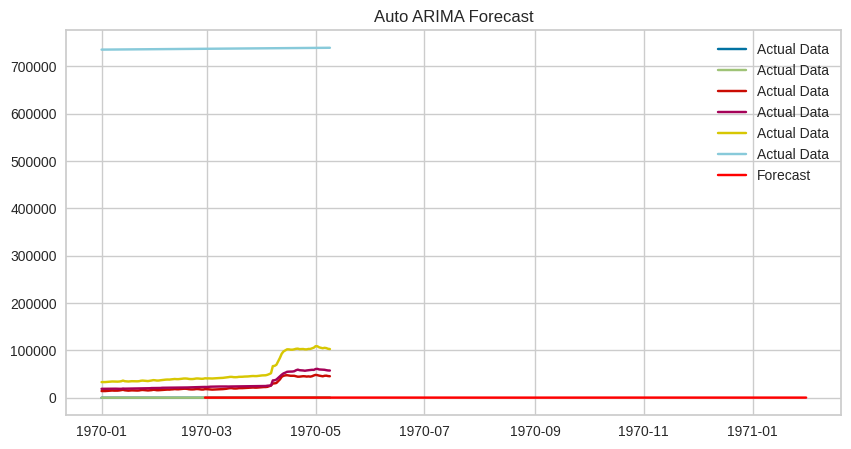

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df, label="Actual Data")
plt.plot(pd.date_range(start=df.index[-1], periods=13, freq='M')[1:], forecast, label="Forecast", color='red')
plt.fill_between(pd.date_range(start=df.index[-1], periods=13, freq='M')[1:],
                 conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title("Auto ARIMA Forecast")
plt.show()

In [ ]:
print(forecast, conf_int)

129    298.683048
130    371.289757
131    399.926076
132    402.546183
133    379.959438
134    342.985720
135    319.181372
136    351.116515
137    387.670608
138    383.285592
139    360.328262
140    345.495090
dtype: float64 [[244.52074157 352.8453537 ]
 [292.08386285 450.49565175]
 [311.6765348  488.17561792]
 [311.42826445 493.66410184]
 [286.06189663 473.85697926]
 [246.38850805 439.58293264]
 [219.9579141  418.40482972]
 [249.33455284 452.89847633]
 [283.39289769 491.94831857]
 [276.57048515 490.00069905]
 [251.23019964 469.42632435]
 [234.06502093 456.92515973]]


# Extra Tree Regressor

In [ ]:
prep_df = pd.read_csv("/content/prepared_long_beans.csv")

In [ ]:
prep_df.isna().sum()

,0
Unnamed: 0,0
index,0
retail_price,0
ncpi_food,0
ncpi_non_food,0
ncpi_all_items,0
date,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           129 non-null    int64  
 1   retail_price    129 non-null    float64
 2   ncpi_food       129 non-null    float64
 3   ncpi_non_food   129 non-null    float64
 4   ncpi_all_items  129 non-null    float64
 5   date            129 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 6.2 KB


In [ ]:
df.tail(12)

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
117,117,322.48,44673.94440,58628.16424,103109.8438,738794
118,118,430.62,45478.07540,59038.56139,104347.1619,738825
119,119,463.04,47115.28612,58861.44571,105808.0221,738855
120,120,521.46,48340.28356,60745.01197,108982.2628,738886
121,121,479.04,47760.20015,61048.73703,108764.2983,738917
122,122,351.62,46757.23595,59827.76229,106480.2480,738946
123,123,251.30,46102.63465,59528.62348,105521.9258,738977
124,124,304.74,45364.99249,59350.03761,104572.2285,739007
125,125,384.32,46453.75231,59112.63746,105513.3785,739038
126,126,408.33,46686.02107,58285.06053,104880.2982,739068


In [ ]:
filtered_df = prep_df.query("date <= 738855")

In [ ]:
filtered_df.tail()

,Unnamed: 0,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
115,115,115,325.31,44767.91225,57701.47850,102291.5117,738733
116,116,116,302.11,45170.82346,58047.68737,103109.8438,738764
117,117,117,322.48,44673.94440,58628.16424,103109.8438,738794
118,118,118,430.62,45478.07540,59038.56139,104347.1619,738825
119,119,119,463.04,47115.28612,58861.44571,105808.0221,738855


In [ ]:
filtered_df.to_csv("filtered_long_beans.csv", index=False)

In [ ]:
filtered_df = pd.read_csv("/content/filtered_long_beans.csv")

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Generate sample dataset
X = filtered_df.drop(columns=["retail_price", "index", "Unnamed: 0"])
y = filtered_df["retail_price"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train Extra Trees Regressor
# n_estimators are the number of decision trees
# criterion is the method on how the branching of the node are determined
# possion give a r2 value of 0.9148 ans mse of 797.4340
etr = ExtraTreesRegressor(n_estimators=100, criterion="absolute_error", random_state=42)
etr.fit(X_train, y_train)

# Predict on test data
y_pred = etr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot results
# plt.scatter(X_test, y_test, color="blue", label="Actual")
# plt.scatter(X_test, y_pred, color="red", label="Predicted")
# plt.xlabel("X")
# plt.ylabel("y")
# plt.legend()
# plt.title("Extra Trees Regressor")
# plt.show()

Mean Squared Error: 424.2641
R² Score: 0.9257


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.4f}")

Mean Squared Error: 424.2641
R² Score: 0.9257
Mean Absolute Error: 15.6434
Root Mean Squared Error: 20.5977
Mean Absolute Percentage Error: 0.0866


In [ ]:
# Comparison_df = pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred_test})
# Comparison_df.to_csv(r'/content/Comparison_df.csv', index=True)
# Comparison_df

In [ ]:
y_test

,retail_price
44,140.69
47,197.72
4,119.51
55,144.23
26,119.94
64,160.71
73,210.00
10,141.77
40,140.76
107,358.84


In [ ]:
y_pred

array([150.7069, 162.1061,  98.1422, 145.513 , 121.9669, 134.6344,
       203.9824, 138.6125, 138.3306, 368.6678, 129.0393, 123.4977,
       172.2738, 133.5104, 186.8173, 184.3272, 349.9967,  90.2977,
       177.3803, 329.3068, 135.1821, 157.5985, 118.506 , 162.34  ,
       141.3221, 197.3803, 110.2254, 362.6011, 147.0424, 268.568 ,
       169.5262, 142.7883, 177.3486, 273.8954, 142.2366, 320.4771])

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Define parameter grid
param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ['sqrt', 'log2', None],
    "criterion": ["squared_error", "absolute_error", "poisson"],
    "bootstrap": [True, False]
}

# Initialize Extra Trees Regressor
etr = ExtraTreesRegressor(random_state=42)

# Perform Randomized Search
random_search = RandomizedSearchCV(
    etr, param_distributions=param_dist, n_iter=50,
    cv=5, scoring="r2", n_jobs=-1, random_state=42
)

random_search.fit(X_train, y_train)

# Get the best model and parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_

# Evaluate the best model
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", best_params)
print(f"Fine-Tuned MSE: {mse:.4f}")
print(f"Fine-Tuned R² Score: {r2:.4f}")


Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'absolute_error', 'bootstrap': False}
Fine-Tuned MSE: 496.3189
Fine-Tuned R² Score: 0.9130


In [ ]:
filtered_df = pd.read_csv("/content/filtered_long_beans.csv")

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split

# Generate sample dataset
X = filtered_df.drop(columns=["retail_price", "index", "Unnamed: 0"])
y = filtered_df["retail_price"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train Extra Trees Regressor
# n_estimators are the number of decision trees
# criterion is the method on how the branching of the node are determined
# possion give a r2 value of 0.9148 ans mse of 797.4340
tuned_etr = ExtraTreesRegressor(n_estimators=100, criterion="absolute_error", max_features="log2", max_depth=30, random_state=42)
tuned_etr.fit(X_train, y_train)

# Predict on test data
y_pred = tuned_etr.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot results
# plt.scatter(X_test, y_test, color="blue", label="Actual")
# plt.scatter(X_test, y_pred, color="red", label="Predicted")
# plt.xlabel("X")
# plt.ylabel("y")
# plt.legend()
# plt.title("Extra Trees Regressor")
# plt.show()

Mean Squared Error: 496.3189
R² Score: 0.9130


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.4f}")

Mean Squared Error: 496.3189
R² Score: 0.9130
Mean Absolute Error: 16.6364
Root Mean Squared Error: 22.2782
Mean Absolute Percentage Error: 0.0907


In [ ]:
import joblib

joblib.dump(tuned_etr, 'etr_long_beans_model.pkl')

['etr_long_beans_model.pkl']

In [ ]:
# X_test.shape

# print(X_test)

In [ ]:
prep_df.tail(9)

,Unnamed: 0,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
120,120,120,521.46,48340.28356,60745.01197,108982.2628,738886
121,121,121,479.04,47760.20015,61048.73703,108764.2983,738917
122,122,122,351.62,46757.23595,59827.76229,106480.2480,738946
123,123,123,251.30,46102.63465,59528.62348,105521.9258,738977
124,124,124,304.74,45364.99249,59350.03761,104572.2285,739007
125,125,125,384.32,46453.75231,59112.63746,105513.3785,739038
126,126,126,408.33,46686.02107,58285.06053,104880.2982,739068
127,127,127,342.04,45845.67269,57702.20993,103411.9741,739099
128,128,128,277.84,45478.90731,57529.10330,102894.9142,739130


In [ ]:
data = {
    "ncpi_food": [48340.28356, 47760.20015, 46757.23595, 46102.63465, 45364.99249, 46453.75231, 46686.02107, 45845.67269, 45478.90731],
    "ncpi_non_food": [60745.01197, 61048.73703, 59827.76229, 59528.62348, 59350.03761, 59112.63746, 58285.06053, 57702.20993, 57529.10330],
    "ncpi_all_items": [108982.2628, 108764.2983, 106480.2480, 105521.9258, 104572.2285, 105513.3785, 104880.2982, 103411.9741, 102894.9142],
    "date": [738886, 738917, 738946, 738977, 739007, 739038, 739068, 739099, 739130]
}

# Create DataFrame
testing_df = pd.DataFrame(data)

In [ ]:
!pip install --upgrade scikit-learn

In [ ]:
print(etr.feature_names_in_)

['ncpi_food' 'ncpi_non_food' 'ncpi_all_items' 'date']


In [ ]:
y_new_pred = etr.predict(testing_df)

In [ ]:
y_new_pred

array([449.8817, 449.8817, 450.6197, 442.5147, 429.8943, 447.7019,
       429.4503, 391.882 , 384.1914])

In [ ]:
prep_df["retail_price"].tail()

,retail_price
124,304.74
125,384.32
126,408.33
127,342.04
128,277.84


In [ ]:
testing_df

,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,48340.28356,60745.01197,108982.2628,738886
1,47760.20015,61048.73703,108764.2983,738917
2,46757.23595,59827.76229,106480.2480,738946
3,46102.63465,59528.62348,105521.9258,738977
4,45364.99249,59350.03761,104572.2285,739007
5,46453.75231,59112.63746,105513.3785,739038
6,46686.02107,58285.06053,104880.2982,739068
7,45845.67269,57702.20993,103411.9741,739099
8,45478.90731,57529.10330,102894.9142,739130


# Linear Regession

In [ ]:
prep_df = pd.read_csv("/content/prepared_long_beans.csv")

In [ ]:
filtered_df = pd.read_csv("/content/filtered_long_beans.csv")

In [ ]:
df.head()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
X = filtered_df.drop(columns=["retail_price", "index", ])
y = filtered_df["retail_price"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size = 0.3)

In [ ]:
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)

X_train shape (84, 5)
X_test shape (36, 5)


In [ ]:
from sklearn.linear_model import LinearRegression

slr_model = LinearRegression()
slr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# y_pred_train = slr_model.predict(X_train)

In [ ]:
y_pred.shape

(36,)

In [ ]:
y_pred = slr_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.4f}")

Mean Squared Error: 1271.0523
R² Score: 0.7773
Mean Absolute Error: 27.3735
Root Mean Squared Error: 35.6518
Mean Absolute Percentage Error: 0.1482


In [ ]:
Comparison_df = pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred})
Comparison_df.to_csv(r'/content/Comparison_df.csv', index=True)
Comparison_df

,Actual,Predicted
44,140.69,160.992323
47,197.72,168.703273
4,119.51,96.190223
55,144.23,143.308672
26,119.94,135.654148
64,160.71,133.384879
73,210.00,172.675876
10,141.77,122.685187
40,140.76,146.200516
107,358.84,361.707773


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Define hyperparameter grid
param_grid = {"alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Initialize Ridge model
ridge = Ridge()

# Perform Grid Search
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_ridge = grid_search.best_estimator_

# Evaluate performance
y_pred = best_ridge.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Ridge Parameters:", grid_search.best_params_)
print(f"Fine-Tuned Ridge MSE: {mse:.4f}")
print(f"Fine-Tuned Ridge R² Score: {r2:.4f}")


Best Ridge Parameters: {'alpha': 0.1}
Fine-Tuned Ridge MSE: 1301.9420
Fine-Tuned Ridge R² Score: 0.7719


In [ ]:
data = {
    "ncpi_food": [48340.28356, 47760.20015, 46757.23595, 46102.63465, 45364.99249, 46453.75231, 46686.02107, 45845.67269, 45478.90731],
    "ncpi_non_food": [60745.01197, 61048.73703, 59827.76229, 59528.62348, 59350.03761, 59112.63746, 58285.06053, 57702.20993, 57529.10330],
    "ncpi_all_items": [108982.2628, 108764.2983, 106480.2480, 105521.9258, 104572.2285, 105513.3785, 104880.2982, 103411.9741, 102894.9142],
    "date": [738886, 738917, 738946, 738977, 739007, 739038, 739068, 739099, 739130]
}

# Create DataFrame
testing_df = pd.DataFrame(data)

In [ ]:
y_new_pred = tuned_etr.predict(testing_df)

In [ ]:
y_new_pred

array([449.8817, 449.8817, 450.6197, 442.5147, 429.8943, 447.7019,
       429.4503, 391.882 , 384.1914])

In [ ]:
prep_df["retail_price"].tail(9)

,retail_price
120,521.46
121,479.04
122,351.62
123,251.30
124,304.74
125,384.32
126,408.33
127,342.04
128,277.84


In [ ]:
# from sklearn.ensemble import ExtraTreesRegressor
# from sklearn.tree import plot_tree
# import matplotlib.pyplot as plt
# from sklearn.datasets import make_regression

# # Generate random regression data
# X, y = make_regression(n_samples=100, n_features=4, random_state=42)

# # Train Extra Trees Regressor
# etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
# etr.fit(X, y)

# # Plot one tree from the ensemble
# plt.figure(figsize=(15, 10))
# plot_tree(etr.estimators_[0], filled=True, feature_names=[f'Feature {i}' for i in range(X.shape[1])])
# plt.show()

# Rigid Regressor

In [ ]:
prep_df = pd.read_csv("/content/prepared_long_beans.csv")

In [ ]:
df.head()

,index,retail_price,ncpi_food,ncpi_non_food,ncpi_all_items,date
0,0,93.59,14198.75000,18921.70000,33139.11000,735234
1,1,91.75,14127.75625,18978.46510,33105.97089,735265
2,2,88.47,14170.13952,18997.44357,33172.18283,735293
3,3,85.06,14411.03189,19054.43590,33470.73248,735324
4,4,119.51,14684.84150,19054.43590,33738.49834,735354


In [ ]:
# Import necessary libraries
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

X = prep_df.drop(columns=["retail_price", "index", ])
y = prep_df["retail_price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Ridge Regression model (with a regularization parameter alpha)
ridge = Ridge(alpha=1.0)

# Train the model on the training data
ridge.fit(X_train, y_train)

# Make predictions
y_pred = ridge.predict(X_test)

# Evaluate the model
print(f"Model Coefficients: {ridge.coef_}")
print(f"Model Intercept: {ridge.intercept_}")

Model Coefficients: [-17.27865868  -0.02293883  -0.03954079   0.03538107   0.56765874]
Model Intercept: -417340.7809608729


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.4f}")

Mean Squared Error: 1293.7954
R² Score: 0.8618
Mean Absolute Error: 23.2123
Root Mean Squared Error: 35.9694
Mean Absolute Percentage Error: 0.1053


In [ ]:
prep_df = pd.read_csv("/content/prepared_long_beans.csv")

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Define parameter distribution
param_dist = {
    "alpha": [0.01, 0.1, 1, 10, 100],  # Regularization strength
    "solver": ["auto", "svd", "cholesky", "lsqr", "sparse_cg", "sag", "saga"]
}

# Initialize Ridge Regression
ridge = Ridge()

# Perform Randomized Search
random_search = RandomizedSearchCV(
    ridge, param_distributions=param_dist, n_iter=10,
    cv=5, scoring="r2", n_jobs=-1, random_state=42
)

random_search.fit(X_train, y_train)

# Get the best model and parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_

# Evaluate the best model
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", best_params)
print(f"Fine-Tuned MSE: {mse:.4f}")
print(f"Fine-Tuned R² Score: {r2:.4f}")


Best Parameters: {'solver': 'svd', 'alpha': 0.1}
Fine-Tuned MSE: 1310.8621
Fine-Tuned R² Score: 0.8600
